In [104]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [105]:
# ============================================================
# CELL 2 — LOAD CLEAN DATASET
# ============================================================

DATASET_PATH = "../parquet_exports/retrieval_dataset_clean.parquet"

df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET LOADED
Rows    : 228,561
Columns : 14


,similarity_pk,ticket_pk,source_system,text_source_type,similarity_method,retrieval_text_clean,corpus_quality_score,similarity_confidence,priority_encoded,urgency_encoded,impact_encoded,text_word_count,text_char_count,repetition_ratio
0,abf40a28ecf0e6c557ae214fb08e74ca,18ecc0b10c975e6a301035cfacf70a70,customer_support_tickets_200k,real_text,nlp_embedding,the payment was deducted from my bank account ...,1.0,0.9,NaN,NaN,NaN,26,159,0.538462
1,bb988e6a04ac835153c4b6cf016f29a8,c00c291d337d61a00615ab907353bc89,customer_support_tickets_200k,real_text,nlp_embedding,i found a bug in the latest update affecting r...,1.0,0.9,NaN,NaN,NaN,22,127,0.500000
2,d111e697dee69897b9c32be8e0832860,b2e3cefec6c77072e59e9aca6a525670,customer_support_tickets_200k,real_text,nlp_embedding,the application crashes whenever i try to uplo...,1.0,0.9,NaN,NaN,NaN,20,113,0.500000
3,62e2c2f208996587aa73c7b6c2756595,9d0370f2cab75492f184db82f51c103f,customer_support_tickets_200k,real_text,nlp_embedding,my subscription was cancelled without my reque...,1.0,0.9,NaN,NaN,NaN,22,149,0.545455
4,231e0b16e61ae075aed6bcb6e76958f7,ff258a55725d78aa9fac5bdeb364d48b,customer_support_tickets_200k,real_text,nlp_embedding,the system is not syncing data across devices ...,1.0,0.9,NaN,NaN,NaN,18,111,0.500000


In [106]:
print("=" * 60)
print("DATA VALIDATION")
print("=" * 60)

print(f"Rows: {len(df):,}")

if "text_source_type" in df.columns:
    print("\nText source distribution:")
    print(df["text_source_type"].value_counts())

if "retrieval_text_clean" in df.columns:
    print(
        "\nEmpty texts:",
        (df["retrieval_text_clean"].fillna("").str.strip() == "").sum()
    )

    print(
        "Average text length:",
        df["retrieval_text_clean"].str.len().mean()
    )

DATA VALIDATION
Rows: 228,561

Text source distribution:
text_source_type
real_text    228561
Name: count, dtype: int64

Empty texts: 0
Average text length: 168.9697454946382


In [107]:
# ============================================================
# CELL 3 — GLOBAL VISUAL STYLE
# ============================================================

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)

print("Visualization style configured.")

Visualization style configured.


In [108]:
print("=" * 60)
print("TEXT LENGTH OUTLIERS")
print("=" * 60)

display(
    df["text_word_count"].describe(
        percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]
    )
)

TEXT LENGTH OUTLIERS


count    228561.000000
mean         26.838367
std          16.646253
min           5.000000
25%          20.000000
50%          22.000000
75%          26.000000
90%          30.000000
95%          73.000000
99%         100.000000
max         201.000000
Name: text_word_count, dtype: float64

In [109]:
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

duplicates = df["retrieval_text_clean"].duplicated().sum()

print(f"Duplicate documents: {duplicates:,}")
print(f"Duplicate ratio: {(duplicates/len(df))*100:.2f}%")

DUPLICATE ANALYSIS
Duplicate documents: 199,990
Duplicate ratio: 87.50%


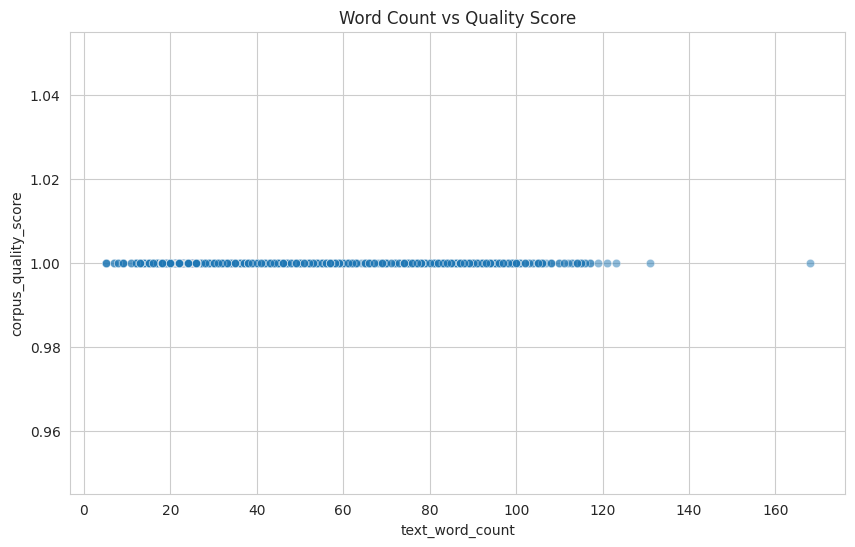

In [110]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(min(5000,len(df))),
    x="text_word_count",
    y="corpus_quality_score",
    alpha=0.5
)

plt.title("Word Count vs Quality Score")
plt.show()

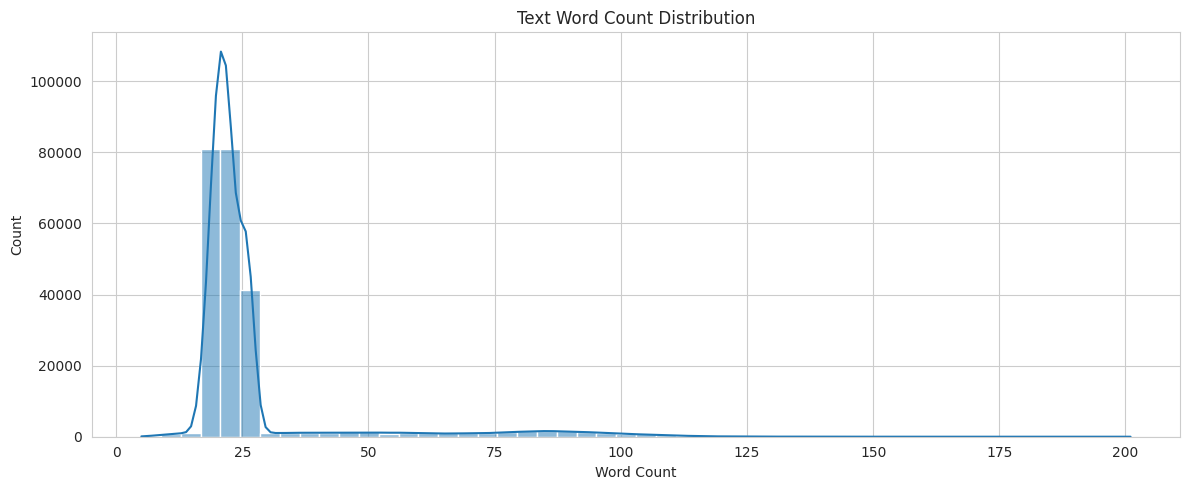

In [111]:
# ============================================================
# CELL 10 — TEXT WORD COUNT DISTRIBUTION
# ============================================================

if "text_word_count" in df.columns:

    plt.figure(figsize=(12, 5))

    sns.histplot(
        df["text_word_count"],
        bins=50,
        kde=True
    )

    plt.title("Text Word Count Distribution")
    plt.xlabel("Word Count")

    plt.tight_layout()
    plt.show()

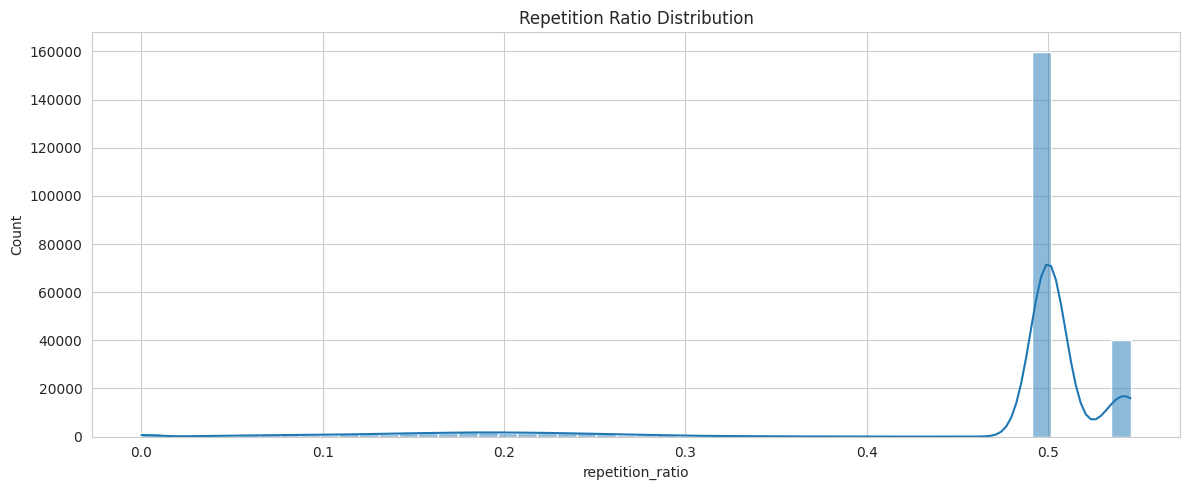

In [112]:
# ============================================================
# CELL 12 — REPETITION RATIO DISTRIBUTION
# ============================================================

if "repetition_ratio" in df.columns:

    plt.figure(figsize=(12, 5))

    sns.histplot(
        df["repetition_ratio"],
        bins=50,
        kde=True
    )

    plt.title("Repetition Ratio Distribution")

    plt.tight_layout()
    plt.show()

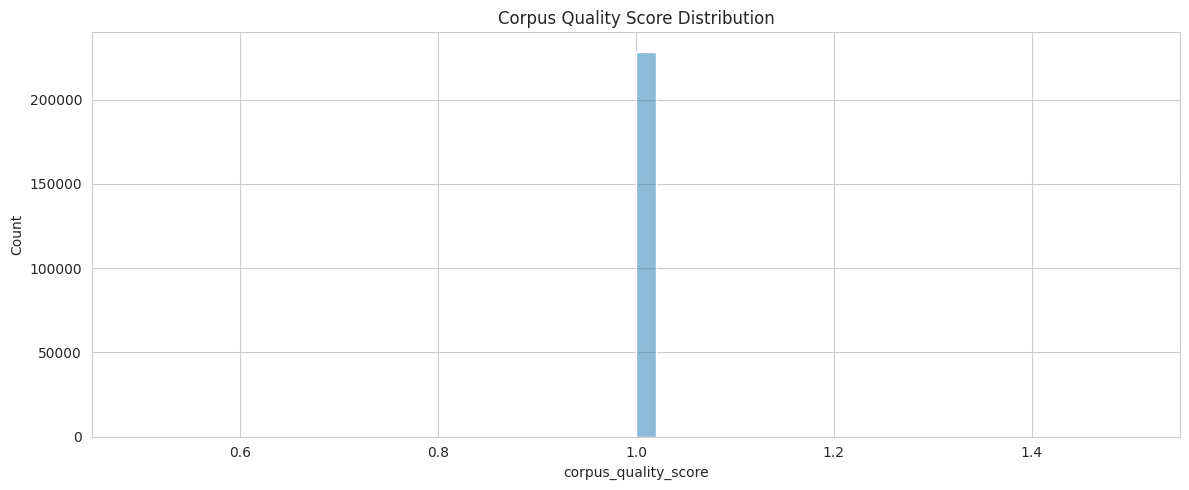

In [113]:
# ============================================================
# CELL 13 — CORPUS QUALITY SCORE DISTRIBUTION
# ============================================================

if "corpus_quality_score" in df.columns:

    plt.figure(figsize=(12, 5))

    sns.histplot(
        df["corpus_quality_score"].dropna(),
        bins=50,
        kde=True
    )

    plt.title("Corpus Quality Score Distribution")

    plt.tight_layout()
    plt.show()

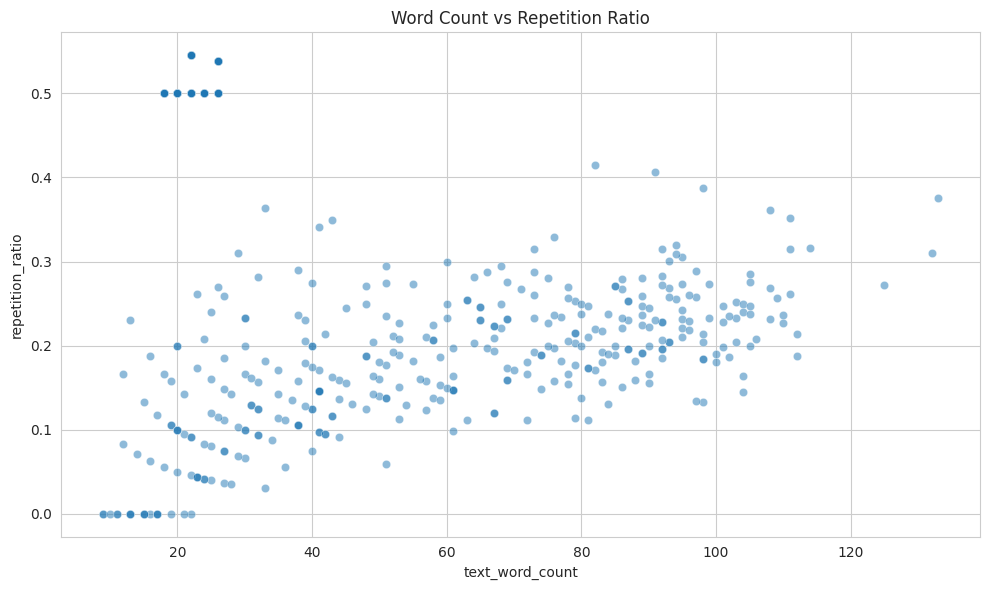

In [114]:
# ============================================================
# CELL 15 — TEXT LENGTH VS REPETITION
# ============================================================

if (
    "text_word_count" in df.columns
    and
    "repetition_ratio" in df.columns
):

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df.sample(min(3000, len(df))),
        x="text_word_count",
        y="repetition_ratio",
        alpha=0.5
    )

    plt.title("Word Count vs Repetition Ratio")

    plt.tight_layout()
    plt.show()


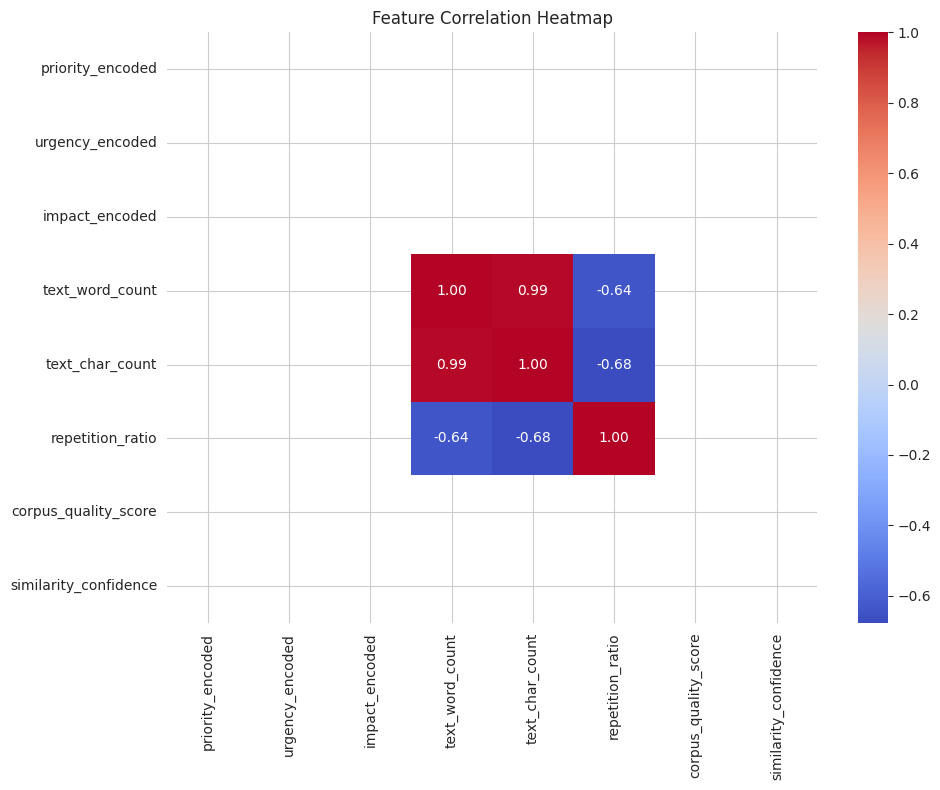

In [115]:
# ============================================================
# CELL 16 — CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    c for c in [
        "priority_encoded",
        "urgency_encoded",
        "impact_encoded",
        "text_word_count",
        "text_char_count",
        "repetition_ratio",
        "corpus_quality_score",
        "similarity_confidence"
    ]
    if c in df.columns
]

corr_df = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [116]:
# ============================================================
# CELL 17 — LONGEST TICKETS
# ============================================================

if (
    "retrieval_text_clean" in df.columns
    and
    "text_char_count" in df.columns
):

    longest_tickets = (
        df.sort_values(
            by="text_char_count",
            ascending=False
        )
        .head(5)
    )

    print("=" * 60)
    print("LONGEST TICKETS")
    print("=" * 60)

    display(
        longest_tickets[
            [
                "ticket_pk",
                "text_char_count",
                "retrieval_text_clean"
            ]
        ]
    )

LONGEST TICKETS


,ticket_pk,text_char_count,retrieval_text_clean
200687,44d709fefbbc72ab32b172a53ceeb67b,1512,anfrage zur architektur-dokumentation der saas...
200163,92503c883e41ca2ae2cbb59d72d0cf67,1470,anfrage zur technischen dokumentation der saas...
200449,d9c22165dfaf76fd24c121d8702d4f47,1371,eilt verf gbarkeitsst rung bei cloud-basiertem...
216202,e58360a77205ca16fe9203db30fa9d00,1240,geehrte kundenservice bitte beraten sie mich i...
205611,3706225e8137c161e327cdfead9603cb,1213,liebe kundensupport ben tige detaillierte doku...


In [117]:
# ============================================================
# CELL 18 — HIGHEST QUALITY TICKETS
# ============================================================

if "corpus_quality_score" in df.columns:

    highest_quality = (
        df.sort_values(
            by="corpus_quality_score",
            ascending=False
        )
        .head(10)
    )

    print("=" * 60)
    print("HIGHEST QUALITY TICKETS")
    print("=" * 60)

    display(
        highest_quality[
            [
                "ticket_pk",
                "corpus_quality_score",
                "retrieval_text_clean"
            ]
        ]
    )


HIGHEST QUALITY TICKETS


,ticket_pk,corpus_quality_score,retrieval_text_clean
0,18ecc0b10c975e6a301035cfacf70a70,1.0,the payment was deducted from my bank account ...
1,c00c291d337d61a00615ab907353bc89,1.0,i found a bug in the latest update affecting r...
2,b2e3cefec6c77072e59e9aca6a525670,1.0,the application crashes whenever i try to uplo...
3,9d0370f2cab75492f184db82f51c103f,1.0,my subscription was cancelled without my reque...
4,ff258a55725d78aa9fac5bdeb364d48b,1.0,the system is not syncing data across devices ...
5,4a2fd89c8c71588afa946976d3656bc8,1.0,there seems to be a discrepancy in my billing ...
6,7e6c2d5cbf9afa0c80ff64db61bee901,1.0,i would like to request a refund for the recen...
7,80ed2e55b6191f526027ca326764a0c2,1.0,two-factor authentication codes are not being ...
8,73818b1c936bd26ddff7bb24eba85bf5,1.0,the payment was deducted from my bank account ...
9,73e65cc15fb05ff6bee24cb1b0289e68,1.0,i am unable to access my account after enterin...


In [118]:
# ============================================================
# CELL 19 — LOWEST QUALITY TICKETS
# ============================================================

if "corpus_quality_score" in df.columns:

    lowest_quality = (
        df.sort_values(
            by="corpus_quality_score",
            ascending=True
        )
        .head(10)
    )

    print("=" * 60)
    print("LOWEST QUALITY TICKETS")
    print("=" * 60)

    display(
        lowest_quality[
            [
                "ticket_pk",
                "corpus_quality_score",
                "retrieval_text_clean"
            ]
        ]
    )

LOWEST QUALITY TICKETS


,ticket_pk,corpus_quality_score,retrieval_text_clean
0,18ecc0b10c975e6a301035cfacf70a70,1.0,the payment was deducted from my bank account ...
1,c00c291d337d61a00615ab907353bc89,1.0,i found a bug in the latest update affecting r...
2,b2e3cefec6c77072e59e9aca6a525670,1.0,the application crashes whenever i try to uplo...
3,9d0370f2cab75492f184db82f51c103f,1.0,my subscription was cancelled without my reque...
4,ff258a55725d78aa9fac5bdeb364d48b,1.0,the system is not syncing data across devices ...
5,4a2fd89c8c71588afa946976d3656bc8,1.0,there seems to be a discrepancy in my billing ...
6,7e6c2d5cbf9afa0c80ff64db61bee901,1.0,i would like to request a refund for the recen...
7,80ed2e55b6191f526027ca326764a0c2,1.0,two-factor authentication codes are not being ...
8,73818b1c936bd26ddff7bb24eba85bf5,1.0,the payment was deducted from my bank account ...
9,73e65cc15fb05ff6bee24cb1b0289e68,1.0,i am unable to access my account after enterin...


In [119]:
# ============================================================
# CELL 20 — RETRIEVAL CORPUS STATISTICS
# ============================================================

print("=" * 60)
print("RETRIEVAL CORPUS STATISTICS")
print("=" * 60)

print(f"Total Tickets            : {len(df):,}")

if "text_word_count" in df.columns:
    print(f"Average Word Count       : {df['text_word_count'].mean():.2f}")
    print(f"Median Word Count        : {df['text_word_count'].median():.2f}")

if "text_char_count" in df.columns:
    print(f"Average Character Count  : {df['text_char_count'].mean():.2f}")

if "repetition_ratio" in df.columns:
    print(f"Average Repetition Ratio : {df['repetition_ratio'].mean():.4f}")

if "source_system" in df.columns:
    print(f"Unique Source Systems    : {df['source_system'].nunique()}")

if "similarity_method" in df.columns:
    print(f"Similarity Methods       : {df['similarity_method'].nunique()}")

RETRIEVAL CORPUS STATISTICS
Total Tickets            : 228,561
Average Word Count       : 26.84
Median Word Count        : 22.00
Average Character Count  : 168.97
Average Repetition Ratio : 0.4669
Unique Source Systems    : 2
Similarity Methods       : 1


In [120]:
# ============================================================
# CELL 21 — CLASS IMBALANCE ANALYSIS
# ============================================================

TARGET_COLUMNS = [
    "priority_encoded",
    "urgency_encoded",
    "impact_encoded"
]

for col in TARGET_COLUMNS:

    if col in df.columns:

        print("\n" + "=" * 60)
        print(f"{col.upper()} DISTRIBUTION")
        print("=" * 60)

        distribution = (
            df[col]
            .value_counts(normalize=True)
            .sort_index()
            * 100
        ).round(2)

        display(distribution)



PRIORITY_ENCODED DISTRIBUTION


Series([], Name: proportion, dtype: float64)


URGENCY_ENCODED DISTRIBUTION


Series([], Name: proportion, dtype: float64)


IMPACT_ENCODED DISTRIBUTION


Series([], Name: proportion, dtype: float64)

In [121]:
eda_summary = {
    "total_rows": len(df),
    "total_columns": df.shape[1],
    "duplicate_ratio": round(
        df["retrieval_text_clean"].duplicated().mean()*100,
        2
    ),
    "avg_word_count": round(
        df["text_word_count"].mean(),
        2
    ),
    "median_word_count": round(
        df["text_word_count"].median(),
        2
    ),
    "avg_quality_score": round(
        df["corpus_quality_score"].mean(),
        2
    )
}

In [122]:
print("=" * 60)
print("RAG READINESS CHECK")
print("=" * 60)

print(
    "Documents for indexing:",
    len(df)
)

print(
    "Average words:",
    round(df["text_word_count"].mean(),2)
)

print(
    "Average quality:",
    round(df["corpus_quality_score"].mean(),2)
)

print(
    "Duplicate ratio:",
    round(
        df["retrieval_text_clean"].duplicated().mean()*100,
        2
    ),
    "%"
)

RAG READINESS CHECK
Documents for indexing: 228561
Average words: 26.84
Average quality: 1.0
Duplicate ratio: 87.5 %


In [124]:
# ============================================================
# CELL last — EXPORT EDA SUMMARY
# ============================================================

from pathlib import Path
import pandas as pd

duplicates = df["retrieval_text_clean"].duplicated().sum()
duplicate_ratio = duplicates / len(df) * 100

eda_summary = {
    "total_documents": len(df),
    "total_columns": df.shape[1],

    "avg_word_count": round(df["text_word_count"].mean(), 2),
    "median_word_count": round(df["text_word_count"].median(), 2),
    "max_word_count": int(df["text_word_count"].max()),

    "avg_character_count": round(
        df["retrieval_text_clean"].str.len().mean(), 2
    ),

    "duplicate_documents": int(duplicates),
    "duplicate_ratio_pct": round(duplicate_ratio, 2),

    "avg_quality_score": round(
        df["corpus_quality_score"].mean(), 4
    ),

    "min_quality_score": round(
        df["corpus_quality_score"].min(), 4
    ),

    "max_quality_score": round(
        df["corpus_quality_score"].max(), 4
    )
}

eda_summary_df = pd.DataFrame([eda_summary])

OUTPUT_DIR = Path("../evaluation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUTPUT_DIR / "eda_summary.csv"

eda_summary_df.to_csv(summary_path, index=False)

print(f"EDA summary saved to: {summary_path}")
display(eda_summary_df)

EDA summary saved to: ../evaluation/eda_summary.csv


,total_documents,total_columns,avg_word_count,median_word_count,max_word_count,avg_character_count,duplicate_documents,duplicate_ratio_pct,avg_quality_score,min_quality_score,max_quality_score
0,228561,14,26.84,22.0,201,168.97,199990,87.5,1.0,1.0,1.0
